In [40]:
# Python functions to import

from collaborative_filtering.baseline_model import *
from collaborative_filtering.fastai_model import *
from collaborative_filtering.lightfm_model import *
from collaborative_filtering.sklearn_model import *
from collaborative_filtering.surprise_model import *

from content_filtering.baseline_model import *
from content_filtering.sklearn_model import *
from content_filtering.tfidf_model import *

In [41]:
# Python libraries to import

import matplotlib.pyplot as plt

In [42]:
# Read in the CSV file

review_data = pd.read_csv("dataset/processed_dataset/review.csv")

In [43]:
# Only keeping users that have made at least 25 reviews

user_counts = review_data['user_id'].value_counts()
filtered_user_ids = user_counts[user_counts > 25].index
review_data = review_data[review_data['user_id'].isin(filtered_user_ids)]

In [44]:
# Undersampling the data so that we can get a more accurate value of how the models are performing

rating_1 = review_data[review_data["stars"] == 1]
rating_2 = review_data[review_data["stars"] == 2]
rating_3 = review_data[review_data["stars"] == 3]
rating_4 = review_data[review_data["stars"] == 4]
rating_5 = review_data[review_data["stars"] == 5]

minimum_sample = min(review_data['stars'].value_counts())

rating_1 = rating_1.sample(minimum_sample, random_state=42)
rating_2 = rating_2.sample(minimum_sample, random_state=42)
rating_3 = rating_3.sample(minimum_sample, random_state=42)
rating_4 = rating_4.sample(minimum_sample, random_state=42)
rating_5 = rating_5.sample(minimum_sample, random_state=42)
 
balanced_df = pd.concat([rating_1,rating_2,rating_3,rating_4,rating_5])


In [45]:
%%capture

# Running each of the models with no hyperparameter optimisation, and making sure the code is not printing anything

baseline_score = collaborative_filtering_baseline(balanced_df)
fastai_score = fastai(balanced_df)
sklearn_score = sklearn(balanced_df)
surprise_score = surprise(balanced_df)
lightfm_score = lightfm(balanced_df)

In [46]:
# Setting up values for the graphing

value_dic = {'Baseline': baseline_score,'FastAI':fastai_score,'Sklearn':sklearn_score,'Surprise':surprise_score,'LightFM':lightfm_score}

In [52]:
# Sorting the data

sorted_data = sorted(value_dic.items(), key=lambda x: x[1])
models, scores = zip(*sorted_data)

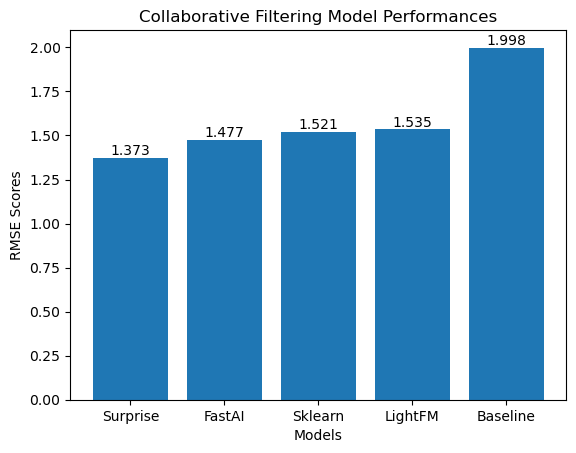

In [53]:
# Graph code

plt.bar(models, scores)

plt.xlabel('Models')
plt.ylabel('RMSE Scores')
plt.title('Collaborative Filtering Model Performances')

for model, score in zip(models, scores):
    rounded_score = round(score, 3)
    plt.text(model, score, str(rounded_score), ha='center', va='bottom')

plt.show()